# SSR Sign-Simplicity-Regression unfolding (sisireg) (`unfold_ssr`)

This notebook applies **SSR Sign-Simplicity-Regression unfolding** — the Python port of the R
package **sisireg** — to a realistic benchmark: detector readings
synthesised from the **Monte-Carlo calculated spectrum
`t4-14-s.txt_1`** of the
[IAEA Compendium](https://www-nds.iaea.org/benchmarks/), a BNCT-like
beam-shaping-assembly spectrum with a thermal group, an epithermal
$1/E$ region and a fast peak.

We use the built-in GSF response functions (10 Bonner spheres, `0in` –
`18in`, 60 energy bins from 1e-9 to ~631 MeV).  Detector readings are
folded with `Detector.get_effective_readings_for_spectra`, the
spectrum is reconstructed with `unfold_ssr`, and the result is
compared against the ground truth — which never enters the unfolding.


Detector grid: 60 bins, 1.0e-09 - 631.0 MeV
Spheres: 0in, 2in, 3in, 5in, 6in, 8in, 10in, 12in, 15in, 18in


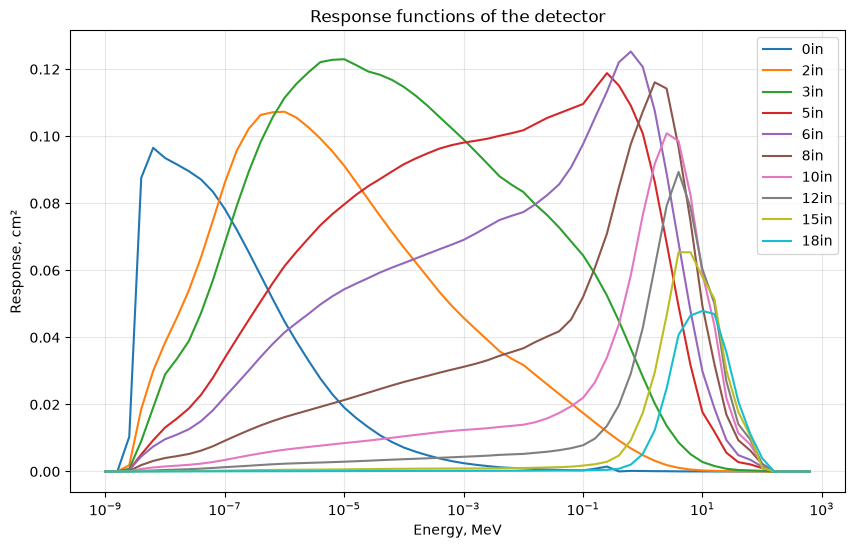

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bssunfold import Detector, RF_GSF
from bssunfold.utils.comparison import compare_spectra

detector = Detector(RF_GSF)
E = detector.E_MeV
names = detector.detector_names
print(f"Detector grid: {detector.n_energy_bins} bins, "
      f"{E[0]:.1e} - {E[-1]:.1f} MeV")
print("Spheres:", ", ".join(names))
detector.plot_response_functions()


## 1. IAEA Compendium reference spectrum → detector readings

The compendium CSV stores 61-point Monte-Carlo spectra on its
own energy grid; `get_effective_readings_for_spectra` folds
the spectrum with the response functions and resamples it
onto the 60-bin detector grid.

Effective readings:
    0in: 0.06677
    2in: 0.0901
    3in: 0.1382
    5in: 0.1639
    6in: 0.1407
    8in: 0.08047
   10in: 0.03924
   12in: 0.01789
   15in: 0.006419
   18in: 0.003085


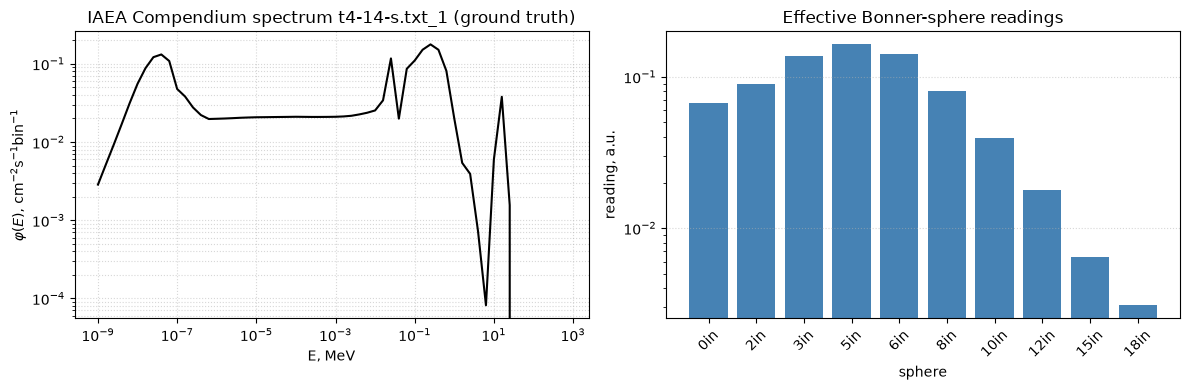

In [2]:
reference_csv = pd.read_csv(
    '../tests/MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv'
)
readings = detector.get_effective_readings_for_spectra(
    reference_csv[['E_MeV', 't4-14-s.txt_1']]
)
print("Effective readings:")
for nm in names:
    print(f"  {nm:>5s}: {readings[nm]:.4g}")

phi_true = np.interp(
    E, reference_csv['E_MeV'].values, reference_csv['t4-14-s.txt_1'].values
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.loglog(E, phi_true, "k-", lw=1.5)
ax.set(xlabel="E, MeV", ylabel=r"$\varphi(E)$, cm$^{-2}$s$^{-1}$bin$^{-1}$",
       title="IAEA Compendium spectrum t4-14-s.txt_1 (ground truth)")
ax.grid(True, which="both", ls=":", alpha=0.5)

ax = axes[1]
vals = [readings[nm] for nm in names]
ax.bar(np.arange(len(names)), vals, color="steelblue")
ax.set_yscale("log")
ax.set_xticks(np.arange(len(names)))
ax.set_xticklabels(names, rotation=45)
ax.set(xlabel="sphere", ylabel="reading, a.u.",
       title="Effective Bonner-sphere readings")
ax.grid(True, axis="y", ls=":", alpha=0.5)
fig.tight_layout()
plt.show()


## 2. SSR unfolding (`fn="auto"`)

`unfold_ssr` (Python port of the R package `sisireg` 1.2.1,
Metzner) alternates MLEM data-fidelity updates with the SSR
quantised Gauss-Seidel parsimony sweeps.  With `fn="auto"` the
partial-sum threshold is chosen by Metzner's minimum-statistic
ladder: the last statistically adequate and most parsimonious
candidate wins.

In [3]:
result = detector.unfold_ssr(readings, save_result=False)

print(f"method          : {result['method']}")
print(f"fn              : {result['fn']}")
print(f"fn_start        : {result['fn_start']}")
print(f"k_run           : {result['k_run']}")
print(f"n_extrema       : {result['n_extrema']}")
print(f"ps_valid_data   : {result['ps_valid_data']}")
print(f"run_valid_data  : {result['run_valid_data']}")
print(f"iterations      : {result['iterations']}  "
      f"(converged: {result['converged']})")

lines_to_plot = [
    (fr"SSR (fn={result['fn']} from auto ladder)", result['spectrum'], "C1-"),
]


method          : SSR
fn              : 2
fn_start        : 5
k_run           : 9
n_extrema       : 5
ps_valid_data   : True
run_valid_data  : True
iterations      : 500  (converged: False)


## 3. Fixed partial-sum thresholds

Explicit `fn` values give coarser/finer parsimony.  A too small
threshold suppresses physically meaningful structure; a too large
one keeps sign-inadequate wiggles.

fn=2: n_extrema= 5  pearson_r=0.732
fn=3: n_extrema= 5  pearson_r=0.730
fn=4: n_extrema= 5  pearson_r=0.704
fn=5: n_extrema= 5  pearson_r=0.698
fn=6: n_extrema= 5  pearson_r=0.709


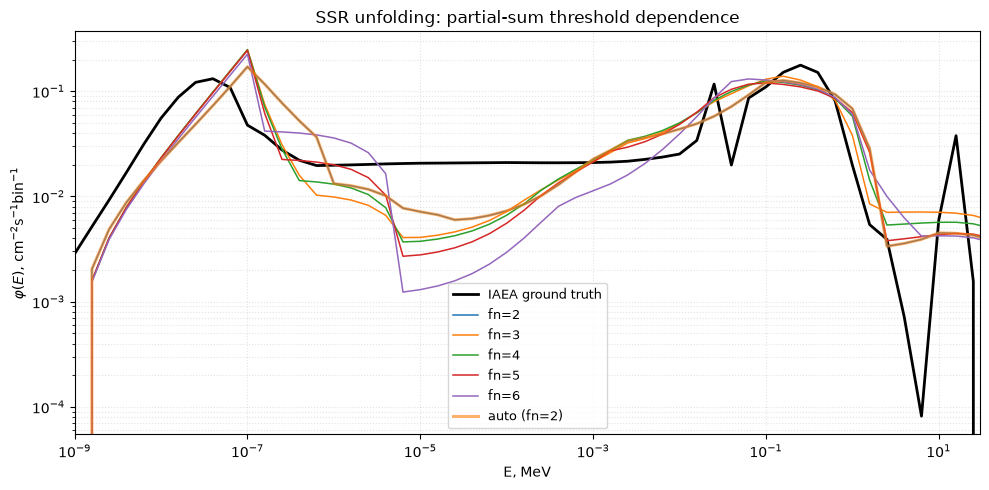

In [4]:
results_fn = {}
for fn in (2, 3, 4, 5, 6):
    res = detector.unfold_ssr(readings, fn=fn, save_result=False)
    results_fn[fn] = res
    q = compare_spectra(
        res['spectrum'], phi_true,
        metrics=['pearson_r', 'relative_flux_error',
                 'comprehensive_score'],
    )
    print(f"fn={fn}: n_extrema={res['n_extrema']:2d}  "
          f"pearson_r={q['pearson_r']:.3f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(E, phi_true, "k-", lw=2, label="IAEA ground truth")
for fn, res in results_fn.items():
    ax.loglog(E, res['spectrum'], lw=1.1, label=f"fn={fn}")
ax.loglog(E, result['spectrum'], color="C1", lw=2.2, alpha=0.6,
          label=f"auto (fn={result['fn']})")
ax.set(xlabel="E, MeV", ylabel=r"$\varphi(E)$, cm$^{-2}$s$^{-1}$bin$^{-1}$",
       title="SSR unfolding: partial-sum threshold dependence")
ax.set_xlim(E[0], 30)
ax.grid(True, which="both", ls=":", alpha=0.35)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


## Quality assessment

`compare_spectra` reports the reconstruction metrics against the
independently known IAEA Compendium spectrum (used only for
evaluation).

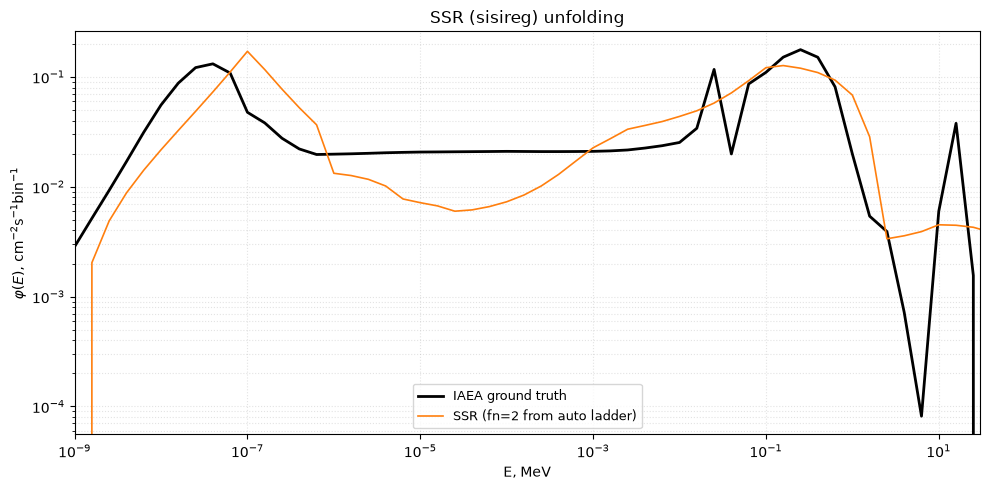

       relative_flux_error: 0.5751202981874083
                 pearson_r: 0.7318119841248508
       comprehensive_score: 0.20921430612498287
fluence_difference_percent: 3.9315843858233044
   dose_difference_percent: 3.931583440278138


In [5]:
quality = compare_spectra(
    result['spectrum'], phi_true,
    metrics=["relative_flux_error", "pearson_r", "comprehensive_score",
             "fluence_difference_percent", "dose_difference_percent"],
    energy=E,
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(E, phi_true, "k-", lw=2, label="IAEA ground truth")
for label, spec, style in lines_to_plot:
    ax.loglog(E, spec, style, lw=1.2, label=label)
ax.set(xlabel="E, MeV", ylabel=r"$\varphi(E)$, cm$^{-2}$s$^{-1}$bin$^{-1}$",
       title="SSR (sisireg) unfolding")
ax.set_xlim(E[0], 30)
ax.grid(True, which="both", ls=":", alpha=0.35)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

for k, v in quality.items():
    print(f"{k:>26s}: {v}")
